In [11]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [12]:
import pandas as pd

df = pd.read_csv('/content/drive/MyDrive/q1_heart_disease.csv')
df.head()

,age,sex,chest_pain_type,resting_bp,cholesterol,fasting_bs,resting_ecg,max_hr,exercise_angina,oldpeak,st_slope,heart_disease
0,68,0,atypical_angina,142.0,399.0,0,left_ventricular_hypertrophy,169,0,0.4,up,1
1,58,1,non_anginal,163.0,310.0,1,st_t_wave_abnormality,121,1,1.1,up,1
2,44,1,non_anginal,128.0,175.0,0,normal,183,1,0.2,up,0
3,72,1,asymptomatic,114.0,177.0,0,st_t_wave_abnormality,150,0,1.0,up,1
4,37,1,non_anginal,149.0,271.0,0,normal,136,0,0.4,flat,0


In [13]:
print("Shape of dataset:", df.shape)
print("\nData Types:\n")
print(df.dtypes)
print("\nMissing Values:\n")
print(df.isnull().sum())
df.head()

Shape of dataset: (800, 12)

Data Types:

age                  int64
sex                  int64
chest_pain_type     object
resting_bp         float64
cholesterol        float64
fasting_bs           int64
resting_ecg         object
max_hr               int64
exercise_angina      int64
oldpeak            float64
st_slope            object
heart_disease        int64
dtype: object

Missing Values:

age                 0
sex                 0
chest_pain_type     0
resting_bp         24
cholesterol        32
fasting_bs          0
resting_ecg         0
max_hr              0
exercise_angina     0
oldpeak             0
st_slope            0
heart_disease       0
dtype: int64


,age,sex,chest_pain_type,resting_bp,cholesterol,fasting_bs,resting_ecg,max_hr,exercise_angina,oldpeak,st_slope,heart_disease
0,68,0,atypical_angina,142.0,399.0,0,left_ventricular_hypertrophy,169,0,0.4,up,1
1,58,1,non_anginal,163.0,310.0,1,st_t_wave_abnormality,121,1,1.1,up,1
2,44,1,non_anginal,128.0,175.0,0,normal,183,1,0.2,up,0
3,72,1,asymptomatic,114.0,177.0,0,st_t_wave_abnormality,150,0,1.0,up,1
4,37,1,non_anginal,149.0,271.0,0,normal,136,0,0.4,flat,0


In [14]:
df.head()

,age,sex,chest_pain_type,resting_bp,cholesterol,fasting_bs,resting_ecg,max_hr,exercise_angina,oldpeak,st_slope,heart_disease
0,68,0,atypical_angina,142.0,399.0,0,left_ventricular_hypertrophy,169,0,0.4,up,1
1,58,1,non_anginal,163.0,310.0,1,st_t_wave_abnormality,121,1,1.1,up,1
2,44,1,non_anginal,128.0,175.0,0,normal,183,1,0.2,up,0
3,72,1,asymptomatic,114.0,177.0,0,st_t_wave_abnormality,150,0,1.0,up,1
4,37,1,non_anginal,149.0,271.0,0,normal,136,0,0.4,flat,0


In [15]:
print(df.shape)
print(df.dtypes)
print(df.isnull().sum())

(800, 12)
age                  int64
sex                  int64
chest_pain_type     object
resting_bp         float64
cholesterol        float64
fasting_bs           int64
resting_ecg         object
max_hr               int64
exercise_angina      int64
oldpeak            float64
st_slope            object
heart_disease        int64
dtype: object
age                 0
sex                 0
chest_pain_type     0
resting_bp         24
cholesterol        32
fasting_bs          0
resting_ecg         0
max_hr              0
exercise_angina     0
oldpeak             0
st_slope            0
heart_disease       0
dtype: int64


### 📌 Data Inspection Summary

The dataset contains 800 observations and 12 features related to patient health, including demographic, clinical, and exercise-related variables.  

The features include both numerical variables (such as age, resting blood pressure, cholesterol, and maximum heart rate) and categorical variables (such as chest pain type, resting ECG results, and ST slope), indicating that preprocessing steps like encoding will be required before modelling.  

Missing values are present in key numerical columns, specifically resting blood pressure (24 missing values) and cholesterol (32 missing values). These will need to be handled carefully during the data preprocessing stage to avoid bias or data loss.  

Overall, the dataset appears well-structured but requires cleaning and transformation before applying machine learning models.

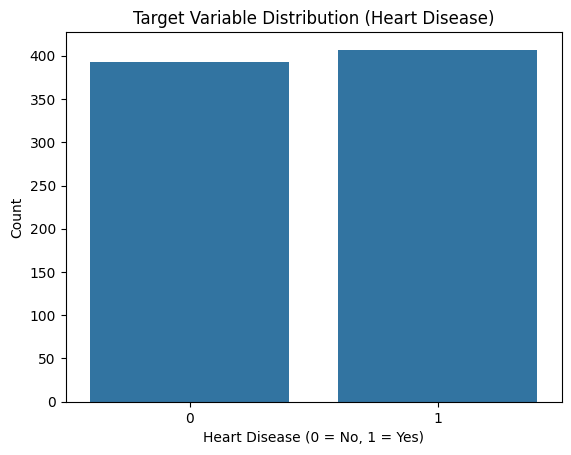

In [20]:
import seaborn as sns
import matplotlib.pyplot as plt

sns.countplot(x='heart_disease', data=df)

plt.title("Target Variable Distribution (Heart Disease)")
plt.xlabel("Heart Disease (0 = No, 1 = Yes)")
plt.ylabel("Count")

plt.show()

### Interpretation — Target Distribution

The plot shows the distribution of patients with and without heart disease.

This helps us understand whether the dataset is balanced or imbalanced. If one class significantly outweighs the other, it may affect model performance and require techniques such as resampling.

A relatively balanced dataset ensures that the model does not become biased toward one class.

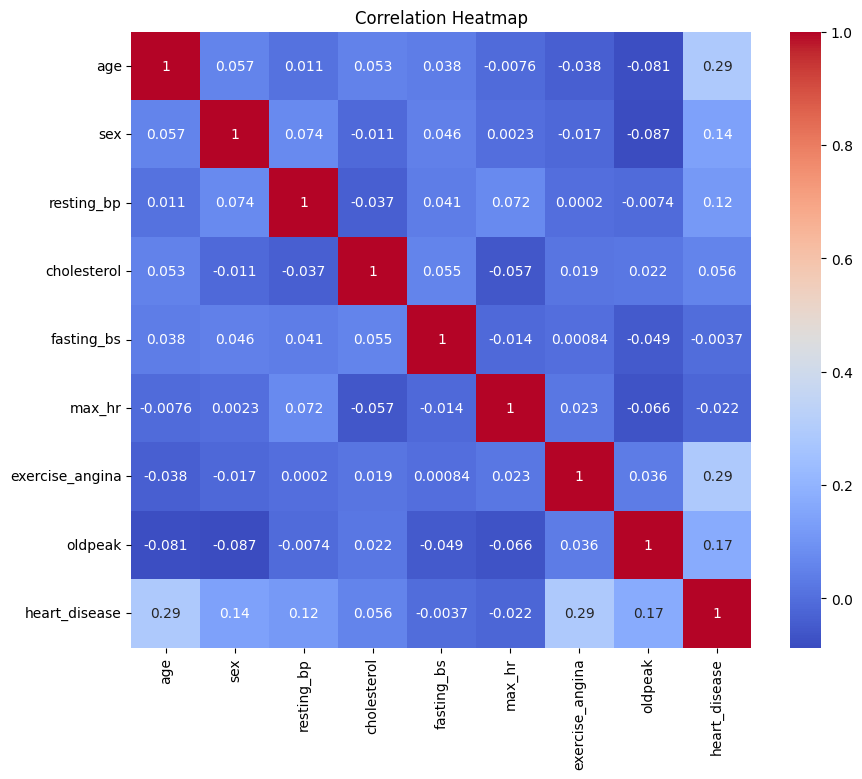

In [21]:
plt.figure(figsize=(10,8))

corr = df.select_dtypes(include=['int64','float64']).corr()

sns.heatmap(corr, annot=True, cmap='coolwarm')

plt.title("Correlation Heatmap")

plt.show()

### Interpretation — Correlation Heatmap

The heatmap shows the relationships between numerical variables in the dataset.

Strong positive or negative correlations indicate variables that may significantly influence the target variable (heart_disease).

For example, features such as max_hr, oldpeak, or cholesterol may show meaningful relationships with heart disease, helping guide feature importance during modelling.

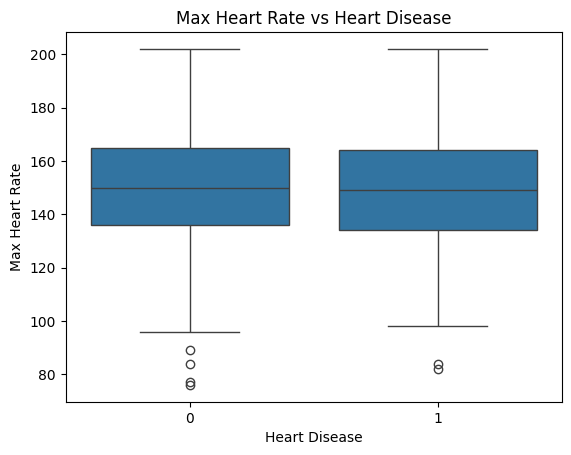

In [22]:
sns.boxplot(x='heart_disease', y='max_hr', data=df)

plt.title("Max Heart Rate vs Heart Disease")
plt.xlabel("Heart Disease")
plt.ylabel("Max Heart Rate")

plt.show()

### Interpretation: Max Heart Rate vs Heart Disease

The boxplot compares maximum heart rate across patients with and without heart disease.

Differences in distribution may indicate that heart rate is an important predictor. For example, lower or more variable heart rates in patients with heart disease could signal reduced cardiovascular efficiency.

Such patterns help identify features that are relevant for classification models.

In [23]:
df['resting_bp'].fillna(df['resting_bp'].median(), inplace=True)
df['cholesterol'].fillna(df['cholesterol'].median(), inplace=True)

/tmp/ipykernel_30684/2285452925.py:1: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df['resting_bp'].fillna(df['resting_bp'].median(), inplace=True)
/tmp/ipykernel_30684/2285452925.py:2: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, in

### Missing Value Treatment

Missing values in resting_bp and cholesterol were handled using median imputation.

Median was chosen instead of mean because it is more robust to outliers, especially in medical datasets where extreme values are common.

This ensures that data is retained without introducing bias from extreme values.

In [25]:
df = pd.get_dummies(df, drop_first=True)

### Encoding Categorical Variables

Categorical variables such as chest_pain_type, resting_ecg, and st_slope were converted into numerical format using one-hot encoding.

This transformation is necessary because machine learning models require numerical input. Dropping the first category helps avoid multicollinearity.

In [26]:
X = df.drop('heart_disease', axis=1)
y = df['heart_disease']

In [27]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, stratify=y, random_state=42
)

In [28]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

### Feature Scaling

Numerical features were scaled using StandardScaler to standardize the data.

Scaling ensures that all features contribute equally to the model and prevents features with larger magnitudes from dominating the learning process.

In [31]:
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier

In [32]:
# Decision Tree
dt_model = DecisionTreeClassifier(random_state=42)
dt_model.fit(X_train, y_train)

# Random Forest
rf_model = RandomForestClassifier(random_state=42)
rf_model.fit(X_train, y_train)

# Gradient Boosting
gb_model = GradientBoostingClassifier(random_state=42)
gb_model.fit(X_train, y_train)

GradientBoostingClassifier(random_state=42)

In [33]:
print("Decision Tree Train Accuracy:", dt_model.score(X_train, y_train))
print("Random Forest Train Accuracy:", rf_model.score(X_train, y_train))
print("Gradient Boosting Train Accuracy:", gb_model.score(X_train, y_train))

Decision Tree Train Accuracy: 1.0
Random Forest Train Accuracy: 1.0
Gradient Boosting Train Accuracy: 0.9609375


### Model Training

Three classification models were trained: Decision Tree, Random Forest, and Gradient Boosting.

All models were initialized with a fixed random_state to ensure reproducibility.

These models were chosen because they are widely used for classification problems and allow comparison between simple and ensemble methods.

In [34]:
from sklearn.metrics import confusion_matrix, classification_report

In [38]:
y_pred_dt = dt_model.predict(X_test)

print("Decision Tree Confusion Matrix:")
print(confusion_matrix(y_test, y_pred_dt))

print("\nDecision Tree Classification Report:")
print(classification_report(y_test, y_pred_dt))


y_pred_rf = rf_model.predict(X_test)

print("Random Forest Confusion Matrix:")
print(confusion_matrix(y_test, y_pred_rf))

print("\nRandom Forest Classification Report:")
print(classification_report(y_test, y_pred_rf))


y_pred_gb = gb_model.predict(X_test)

print("Gradient Boosting Confusion Matrix:")
print(confusion_matrix(y_test, y_pred_gb))

print("\nGradient Boosting Classification Report:")
print(classification_report(y_test, y_pred_gb))

Decision Tree Confusion Matrix:
[[57 22]
 [25 56]]

Decision Tree Classification Report:
              precision    recall  f1-score   support

           0       0.70      0.72      0.71        79
           1       0.72      0.69      0.70        81

    accuracy                           0.71       160
   macro avg       0.71      0.71      0.71       160
weighted avg       0.71      0.71      0.71       160

Random Forest Confusion Matrix:
[[61 18]
 [15 66]]

Random Forest Classification Report:
              precision    recall  f1-score   support

           0       0.80      0.77      0.79        79
           1       0.79      0.81      0.80        81

    accuracy                           0.79       160
   macro avg       0.79      0.79      0.79       160
weighted avg       0.79      0.79      0.79       160

Gradient Boosting Confusion Matrix:
[[61 18]
 [19 62]]

Gradient Boosting Classification Report:
              precision    recall  f1-score   support

           0    

### Model Evaluation Summary

All three models were evaluated using confusion matrix, precision, recall, and F1-score.

Among the models, Random Forest performed the best, achieving the highest F1-score along with a strong balance between precision and recall.

The confusion matrix also shows that Random Forest makes fewer misclassifications compared to the other models, indicating better overall predictive performance.

While accuracy provides a general measure, the F1-score is more reliable in this case as it balances both false positives and false negatives, which is crucial for medical prediction tasks like heart disease detection.

In [39]:
from sklearn.model_selection import GridSearchCV

param_grid = {
    'n_estimators': [50, 100],
    'max_depth': [None, 10, 20],
    'min_samples_split': [2, 5]
}

grid_search = GridSearchCV(
    estimator=RandomForestClassifier(random_state=42),
    param_grid=param_grid,
    cv=5,
    scoring='f1',
    n_jobs=-1
)

grid_search.fit(X_train, y_train)

print("Best Parameters:", grid_search.best_params_)

best_model = grid_search.best_estimator_

y_pred_best = best_model.predict(X_test)

from sklearn.metrics import classification_report

print("Tuned Model Performance:\n")
print(classification_report(y_test, y_pred_best))

Best Parameters: {'max_depth': 10, 'min_samples_split': 5, 'n_estimators': 100}
Tuned Model Performance:

              precision    recall  f1-score   support

           0       0.79      0.75      0.77        79
           1       0.76      0.80      0.78        81

    accuracy                           0.78       160
   macro avg       0.78      0.77      0.77       160
weighted avg       0.78      0.78      0.77       160



### Hyperparameter Tuning Summary

GridSearchCV was used to tune the Random Forest model by testing different combinations of hyperparameters such as number of estimators, maximum depth, and minimum samples required for splitting.

The best parameters obtained were: max_depth = 10, min_samples_split = 5, and n_estimators = 100.

After tuning, the model showed similar but slightly lower performance compared to the baseline model in terms of F1-score.

This indicates that the default Random Forest model was already well-suited for this dataset, and further tuning did not significantly improve its predictive capability.